## Inspección del CSV

In [2]:
import pandas as pd

df = pd.read_csv("GlobalLandTemperaturesByCountry.csv")

df.head()


,dt,AverageTemperature,AverageTemperatureUncertainty,Country
0,1743-11-01,4.384,2.294,Åland
1,1743-12-01,NaN,NaN,Åland
2,1744-01-01,NaN,NaN,Åland
3,1744-02-01,NaN,NaN,Åland
4,1744-03-01,NaN,NaN,Åland


In [68]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 577462 entries, 0 to 577461
Data columns (total 4 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   dt                             577462 non-null  object 
 1   AverageTemperature             544811 non-null  float64
 2   AverageTemperatureUncertainty  545550 non-null  float64
 3   Country                        577462 non-null  object 
dtypes: float64(2), object(2)
memory usage: 17.6+ MB


In [69]:
df.describe()

,AverageTemperature,AverageTemperatureUncertainty
count,544811.000000,545550.000000
mean,17.193354,1.019057
std,10.953966,1.201930
min,-37.658000,0.052000
25%,10.025000,0.323000
50%,20.901000,0.571000
75%,25.814000,1.206000
max,38.842000,15.003000


<div>

• <b>Count</b>: number of valid (non-null) numerical values<br>
  → Helps identify missing data

• <b>Mean</b>: average value<br>
  → Central tendency of the distribution

• <b>Std (Standard Deviation)</b>: spread of the data<br>
&nbsp;&nbsp;&nbsp;&nbsp;• low std → stable data<br>
&nbsp;&nbsp;&nbsp;&nbsp;• high std → highly variable data<br>
  → Measures variability around the mean

• <b>Min</b>: minimum value (coldest extreme in this case)<br>
  → Possible outliers or extreme events

• <b>25% (Q1)</b>: 25th percentile<br>
  → 25% of values are below this point (cooler range)

• <b>50% (Median)</b>: middle value<br>
  → Splits the dataset in half<br>
  → More robust than mean (less sensitive to outliers)

• <b>75% (Q3)</b>: 75th percentile<br>
  → 75% of values are below this point (warmer range)

• <b>Max</b>: maximum value (hottest extreme in this case)<br>
  → Possible outliers or extreme events

</div>

In [70]:
df.columns

Index(['dt', 'AverageTemperature', 'AverageTemperatureUncertainty', 'Country'], dtype='object')

In [71]:
df.isnull().sum()

dt                                   0
AverageTemperature               32651
AverageTemperatureUncertainty    31912
Country                              0
dtype: int64

In [72]:
df.duplicated().sum()

0

In [73]:
df[df["AverageTemperature"] > 60]
df[df["AverageTemperature"] < -90]

,dt,AverageTemperature,AverageTemperatureUncertainty,Country


## Convirtiendo fechas 

In [74]:
df["dt"] = pd.to_datetime(df["dt"])
df["year"] = df["dt"].dt.year
df["month"] = df["dt"].dt.month

# Gráficos Simples

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

## Aumento de la temperatura global

In [76]:
yearly = df.groupby("year")["AverageTemperature"].mean()


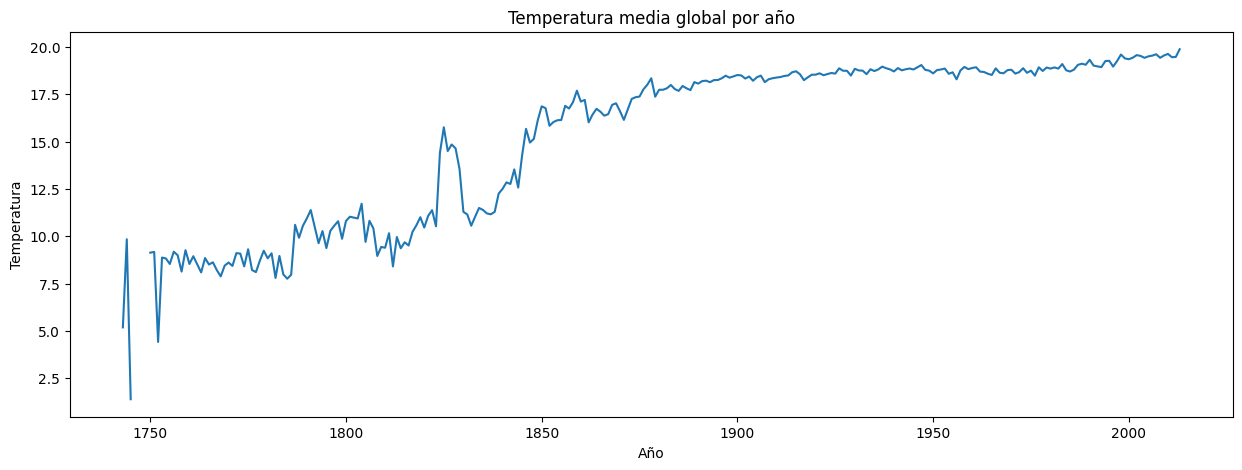

In [77]:
plt.figure(figsize=(15,5))
plt.plot(yearly.index, yearly.values)
plt.title("Temperatura media global por año")
plt.xlabel("Año")
plt.ylabel("Temperatura")
plt.show()

### Picos extraños: ~1825~
### Valores imposibles: None
### Años faltantes: ~1750~

In [78]:
# Check year and month columns
df.head()

,dt,AverageTemperature,AverageTemperatureUncertainty,Country,year,month
0,1743-11-01,4.384,2.294,Åland,1743,11
1,1743-12-01,NaN,NaN,Åland,1743,12
2,1744-01-01,NaN,NaN,Åland,1744,1
3,1744-02-01,NaN,NaN,Åland,1744,2
4,1744-03-01,NaN,NaN,Åland,1744,3


<Axes: xlabel='year', ylabel='AverageTemperature'>

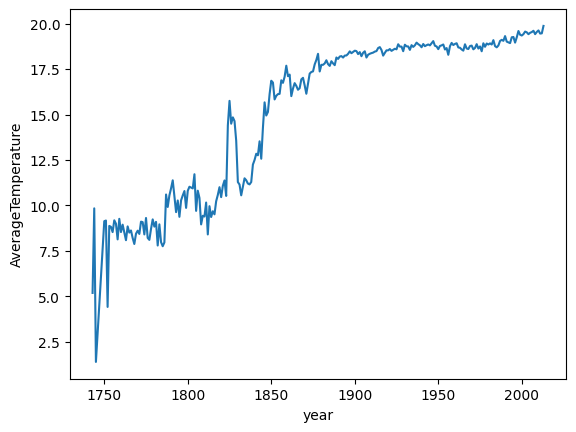

In [79]:
sns.lineplot(data=df,  x="year", y="AverageTemperature", errorbar=None)

## Distribución

<Axes: xlabel='AverageTemperature', ylabel='Count'>

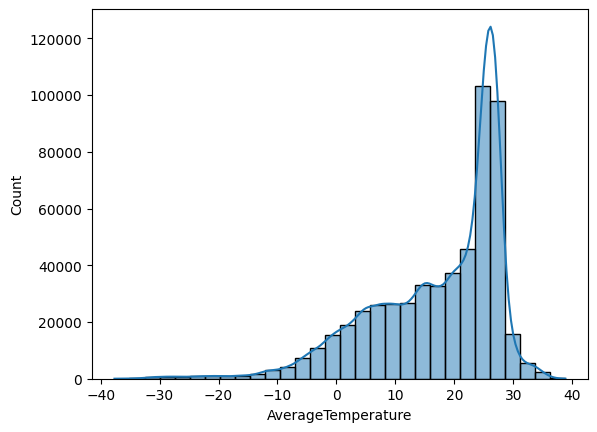

In [80]:
sns.histplot(df["AverageTemperature"], bins=30, kde=True)

### Forma unimodal aproximadamente acampanada. Cierta asimetria con sesgo hacia la izquierda. Parece razonable al ser una serie climática global.

<h2 style="margin: 8px 0 4px 0;">Media móvil (MA: Moving Average)</h3>
<div style="line-height: 1.75;">Suavización de ruido:<br>
&bull; En cada punto se calcula el promedio de los ultimos N puntos (MA_N)<br>
&bull; En este caso MA_10 al tratarse de una serie Mensual con bastantes cambios estacionales<br>
&bull; Recomendado MA_3 o MA_5 para series horarias/diarias. Pero diferencia case by case<br>
</div>

In [81]:
# Moving average of 10 months  
df["MA_10"] = df["AverageTemperature"].rolling(10).mean()

# dt to datatime already done

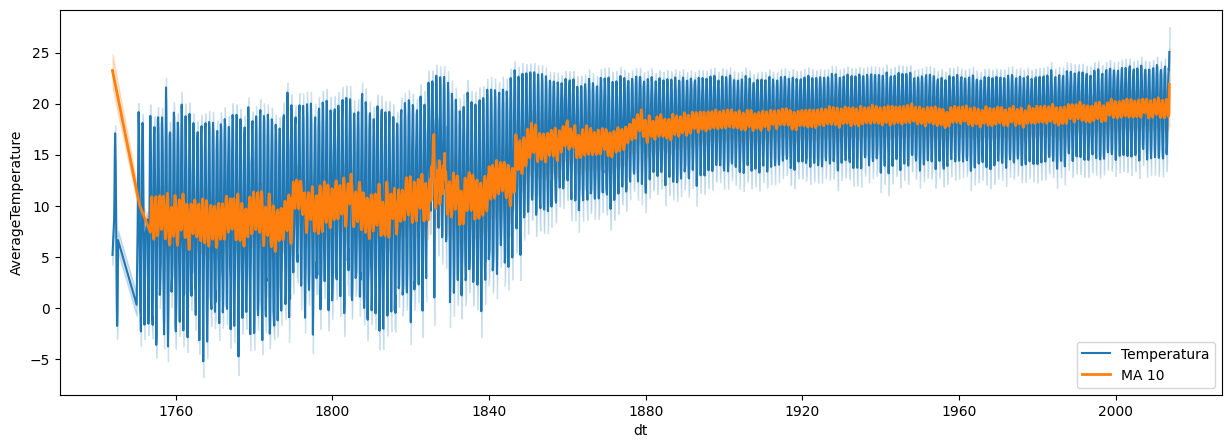

In [82]:
plt.figure(figsize=(15,5))
sns.lineplot(data=df, x="dt", y="AverageTemperature", label="Temperatura")
sns.lineplot(data=df, x="dt", y="MA_10", label="MA 10", linewidth=2)

plt.show()

<h3 style="margin: 8px 0 4px 0;">Línea móvil</h3>
<div style="line-height: 1.25;">
<span style="color:blue;">Azul:</span> Variabilidad climática real (Estacional + extremos)<br>
<span style="color:darkorange;">Naranja:</span> Tendencia subyacente del clima
</div>

### Estudio de cambio climático con MA 50

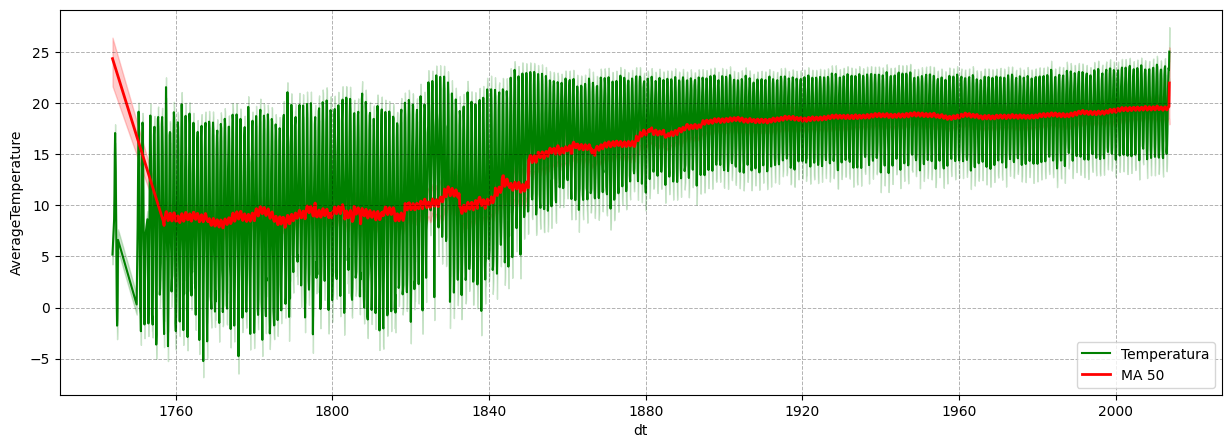

In [83]:
df["MA_50"] = df["AverageTemperature"].rolling(50).mean()
# Ligero cambio de color para diferenciar mejor las líneas
plt.figure(figsize=(15,5))
ax = plt.gca() # Obtener el eje actual para ajustar el grid encima de las líneas

sns.lineplot(
    data=df,
    x="dt",
    y="AverageTemperature",
    label="Temperatura",
    linewidth=1.5,
    color="green")
sns.lineplot(
    data=df,
    x="dt",
    y="MA_50",
    label="MA 50",
    linewidth=2,
    color="red")

# Ajustar el grid para que esté encima de las líneas
ax.set_axisbelow(False)
ax.grid(
    True,
    color = "black",
    linewidth=0.7,
    alpha=0.3,
    linestyle="--"
)

plt.show()

## Correlación Temporal
#### Cambios de temperatura mes a mes

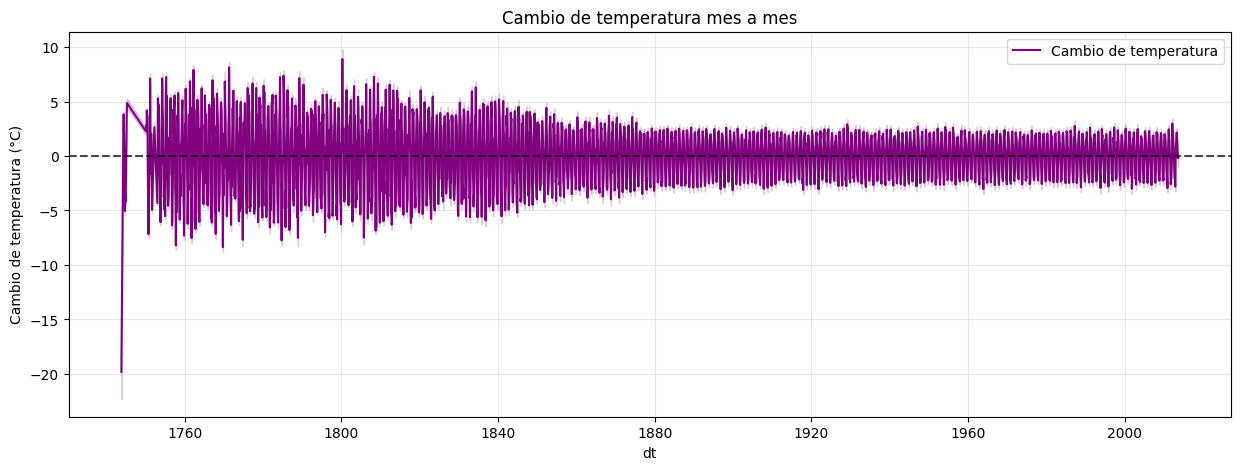

In [84]:
df["temp_change"] = df["AverageTemperature"].diff() 
plt.figure(figsize=(15,5))
sns.lineplot(data=df, x="dt", y="temp_change", label="Cambio de temperatura", color="purple")
plt.axhline(0, color="black", linestyle="--", alpha=0.7)
plt.grid(True, alpha=0.3)
plt.title("Cambio de temperatura mes a mes")    
plt.ylabel("Cambio de temperatura (°C)")

plt.show()

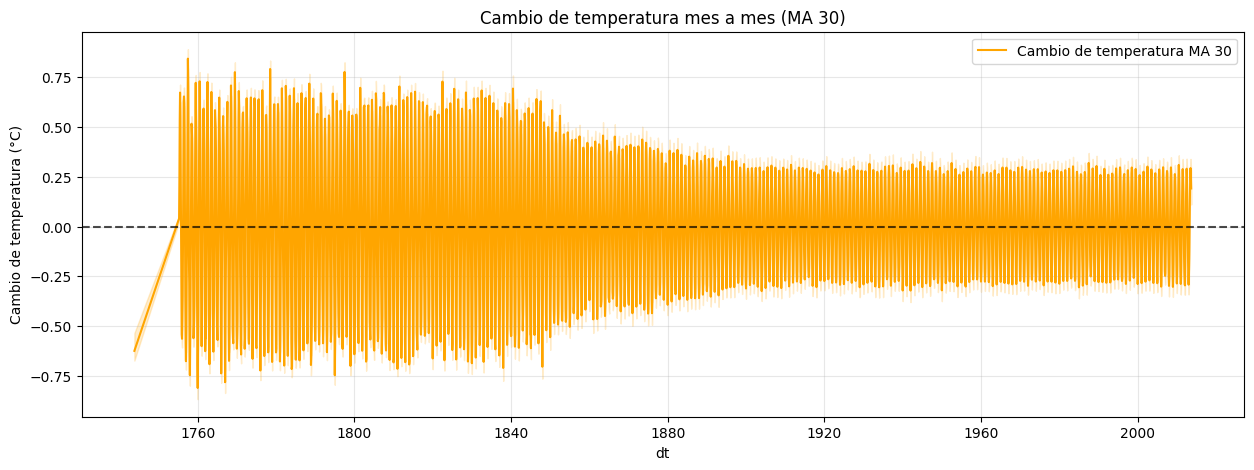

In [85]:
# Suavizamos el cambio de temperatura con una media móvil de 30 meses
df["temp_change_MA30"] = df["temp_change"].rolling(30).mean()
plt.figure(figsize=(15,5))
sns.lineplot(data=df, x="dt", y="temp_change_MA30", label="Cambio de temperatura MA 30", color="orange")
plt.axhline(0, color="black", linestyle="--", alpha=0.7)
plt.grid(True, alpha=0.3)
plt.title("Cambio de temperatura mes a mes (MA 30)")    
plt.ylabel("Cambio de temperatura (°C)")

plt.show()

#### La variabilidad del cambio de temperatura mensual es menor en el periodo moderno, lo que puede reflejar tanto una mayor estabilidad en las series recientes como, muy probablemente, una mejora en la calidad y consistencia de las mediciones a partir de finales del siglo XIX

## ¿Es cada década más caliente a la anterior?

In [86]:
df["decade"] = (df["dt"].dt.year // 10) * 10
decadal_mean = df.groupby("decade")["AverageTemperature"].mean().sort_index()
decadal_change = decadal_mean.diff()

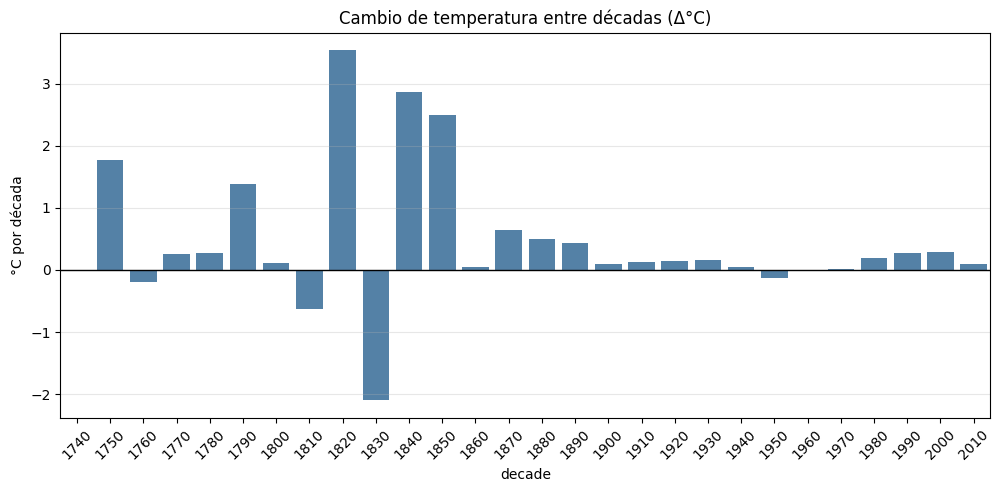

In [89]:
plt.figure(figsize=(12,5))

sns.barplot(x=decadal_change.index, y=decadal_change.values, color="steelblue")

plt.axhline(0, color="black", linewidth=1)
plt.xticks(rotation=45)
plt.title("Cambio de temperatura entre décadas (Δ°C)")
plt.ylabel("°C por década")
plt.grid(True, axis="y", alpha=0.3)

#### A partir de 1880 vemos como hay un incremento pequeño pero estable década a década de la temperatura global
#### Aunque anteriormente los cambios son más bruscos, podemos achacarlo a que los métodos de medida no eran tan exactos como en épocas más recientes

In [91]:
df_1880 = df[df["year"] >= 1880]
dec_from_1880 = df_1880.groupby("decade")["AverageTemperature"].mean().sort_index()
dec_from_1880_change = dec_from_1880.diff()

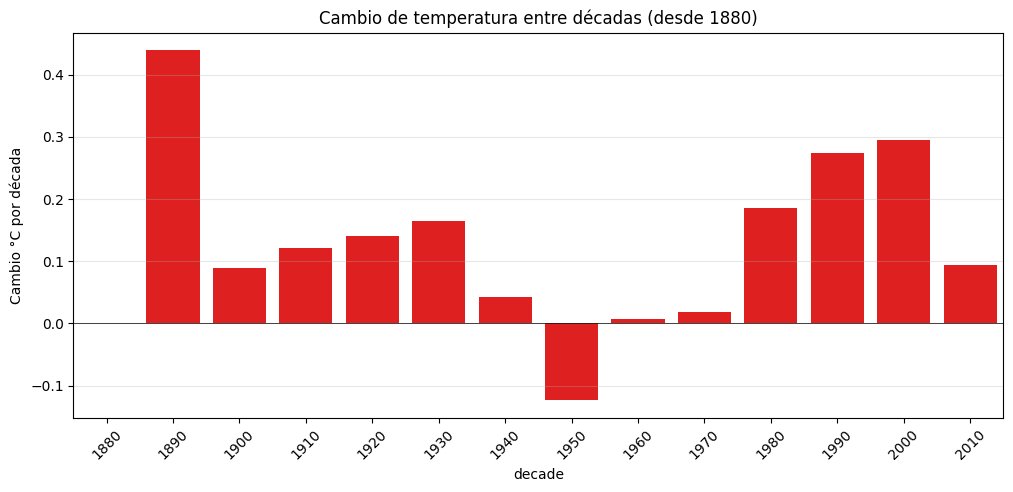

In [92]:
plt.figure(figsize=(12,5))

sns.barplot(x=dec_from_1880_change.index, y=dec_from_1880_change.values, color="red")

plt.axhline(0, color="black", linewidth=0.5)
plt.xticks(rotation=45)
plt.title("Cambio de temperatura entre décadas (desde 1880)")
plt.ylabel("Cambio °C por década")
plt.grid(True, axis="y", alpha=0.3)

plt.show()

In [96]:
nan_by_decade = df_1880.groupby("decade")["AverageTemperature"].apply(lambda x: x.isna().sum())
print(nan_by_decade)

decade
1880    1474
1890     134
1900      51
1910       0
1920       5
1930       1
1940       6
1950     121
1960     120
1970     120
1980     120
1990     120
2000     120
2010     266
Name: AverageTemperature, dtype: int64


In [97]:
count_by_decade = df_1880.groupby("decade")["AverageTemperature"].count()
print(count_by_decade)

decade
1880    26810
1890    28368
1900    28677
1910    28800
1920    28795
1930    28799
1940    28840
1950    29038
1960    29040
1970    29040
1980    29040
1990    29040
2000    29040
2010    10669
Name: AverageTemperature, dtype: int64


In [98]:
missing_pct = nan_by_decade / (nan_by_decade + count_by_decade) * 100
print(missing_pct)

decade
1880    5.211427
1890    0.470142
1900    0.177527
1910    0.000000
1920    0.017361
1930    0.003472
1940    0.020800
1950    0.414966
1960    0.411523
1970    0.411523
1980    0.411523
1990    0.411523
2000    0.411523
2010    2.432556
Name: AverageTemperature, dtype: float64


In [93]:
from scipy.stats import linregress

df_1880 = df[df["dt"].dt.year >= 1880].copy()

df_1880["decade"] = (df_1880["dt"].dt.year // 10) * 10
dec = df_1880.groupby("decade")["AverageTemperature"].mean()

x = dec.index.values
y = dec.values

slope, intercept, r, p, std = linregress(x, y)

In [94]:
slope_per_decade = slope * 10
print(slope_per_decade)

0.10300271721357794


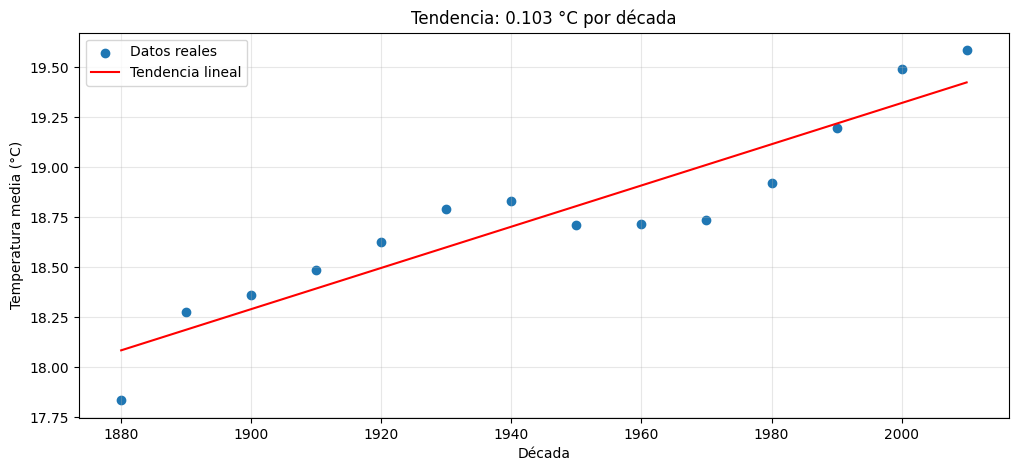

In [95]:
plt.figure(figsize=(12,5))

plt.scatter(x, y, label="Datos reales")
plt.plot(x, intercept + slope*x, color="red", label="Tendencia lineal")

plt.title(f"Tendencia: {slope_per_decade:.3f} °C por década")
plt.xlabel("Década")
plt.ylabel("Temperatura media (°C)")
plt.legend()
plt.grid(True, alpha=0.3)

plt.show()

# MAPAMUNDI

In [3]:
import plotly.express as px
import pycountry
import pandas as pd

def get_iso3(country):
    try:
        return pycountry.countries.lookup(country).alpha_3
    except:
        return None

df["iso_alpha"] = df["Country"].apply(get_iso3)

# limpieza
df["dt"] = pd.to_datetime(df["dt"])

# promedio por país
country_temp = df.groupby("Country")["AverageTemperature"].mean().reset_index()

# añadir ISO al dataset agregado
country_temp["iso_alpha"] = country_temp["Country"].apply(get_iso3)

fig = px.choropleth(
    country_temp,
    locations="iso_alpha",
    color="AverageTemperature",
    color_continuous_scale="RdYlBu_r",
    title="Global Average Temperature by Country"
)

fig.show()



In [5]:

df["dt"] = pd.to_datetime(df["dt"])

# 🔥 anomalía global (baseline)
df["anomaly"] = df["AverageTemperature"] - df["AverageTemperature"].mean()

# 📊 agregar por país
country_anomaly = df.groupby("Country")["anomaly"].mean().reset_index()

# 🌍 convertir a ISO-3
country_anomaly["iso_alpha"] = country_anomaly["Country"].apply(get_iso3)

# 🗺️ mapa correcto
fig = px.choropleth(
    country_anomaly,
    locations="iso_alpha",
    color="anomaly",
    color_continuous_scale="RdBu_r",
    title="Global Temperature Anomaly by Country"
)

fig.show()

In [8]:
df["dt"] = pd.to_datetime(df["dt"])
df["year"] = df["dt"].dt.year.astype(int)

country_year = df.groupby(["Country", "year"])["AverageTemperature"].mean().reset_index()
country_year["iso_alpha"] = country_year["Country"].apply(get_iso3)

country_year = country_year.sort_values("year")

fig = px.choropleth(
    country_year,
    locations="iso_alpha",
    color="AverageTemperature",
    animation_frame="year",
    color_continuous_scale="RdYlBu_r",
    title="Global Temperature Evolution by Country"
)

fig.show()